# Test black-box allocation baselines

This notebook is a small end-to-end smoke test for the direct black-box allocation models in `models/src/blackbox_baselines.py`. It uses the shared data loading and capital-allocation functions from `capital_allocation_utils.py`, trains linear and MLP allocators, and evaluates out-of-sample decision performance.

In [ ]:
from pathlib import Path
import sys


import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()

while ROOT != ROOT.parent and not (ROOT / "models" / "src" / "blackbox_baselines.py").exists():
    print("Checking:", ROOT)
    ROOT = ROOT.parent

print("blackbox file exists:", (ROOT / "models" / "src" / "blackbox_baselines.py").exists())

sys.path.insert(0, str(ROOT / "models" / "src"))

from capital_allocation_utils import CapitalConfig, ModelConfig, chronological_split, load_and_align_data

from blackbox_baselines import (
    build_blackbox_prediction_frame,
    evaluate_alpha_predictions,
    predict_alpha,
    run_expanding_window,
    train_blackbox_model,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.6f}".format)

ROOT

1. Starting imports
2. matplotlib imported
3. numpy imported
4. pandas imported
5. sklearn imported
6. Starting ROOT search from: /homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation/models/notebooks
Checking: /homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation/models/notebooks
Checking: /homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation/models
7. Found ROOT: /homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation
blackbox file exists: True
8. Added to sys.path: /homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation/models/src
9. Imported capital_allocation_utils
10. Imported blackbox_baselines


PosixPath('/homes/heo25/Documents/Decision_Focused_Learning_for_Capital_Allocation')

## Load and align data

`macro_panel_quarterly.csv` is dated at quarter end, while `fred_loan_return_aligned.csv` is dated at quarter start. The temporary macro copy below converts macro dates to quarter start before calling the shared `load_and_align_data` utility.

In [2]:
macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
results_dir = ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)

macro = pd.read_csv(macro_csv)
macro["DATE"] = pd.to_datetime(macro["DATE"]).dt.to_period("Q").dt.start_time
macro_aligned_csv = ROOT / "data/processed/" "macro_panel_quarter_start.csv"
macro.to_csv(macro_aligned_csv, index=False)

df = load_and_align_data(
    macro_csv=macro_aligned_csv,
    chargeoff_csv=chargeoff_csv,
    date_col="DATE",
    target_col="charge_off_rate",
    feature_cols=None,
    horizon=1,
    target_is_percent=True,
)

feature_cols = df.attrs["feature_cols"]
print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")

display(df.head())
display(df.tail())

assert len(df) > 40
assert df[feature_cols + ["target_chargeoff_next"]].notna().all().all()

Observations after alignment and one-step target: 143
Date range: 1990-04-01 to 2025-10-01
Features (12): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium']


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
0,1990-04-01,1.500000,5.333333,0.684295,0.736741,0.984464,0.423064,8.243333,0.103016,18.722063,1.638730,54.400000,0.146990,0.014300,1990-07-01,0.012800
1,1990-07-01,0.300000,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,1.706190,46.700000,-0.047302,0.012800,1990-10-01,0.013000
2,1990-10-01,-3.600000,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,2.197419,54.200000,0.266956,0.013000,1991-01-01,0.014800
3,1991-01-01,-1.900000,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,2.186500,38.600000,0.305454,0.014800,1991-04-01,0.018600
4,1991-04-01,3.200000,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,1.795937,20.000000,0.162705,0.018600,1991-07-01,0.019700


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,corporate_bond_spread,senior_loan_officer_survey,excess_bond_premium,charge_off_rate,target_date,target_chargeoff_next
138,2024-10-01,1.900000,4.133333,-0.375669,0.494028,0.782193,0.549054,4.650000,0.130000,17.363231,1.459032,0.000000,-0.327843,0.005200,2025-01-01,0.005500
139,2025-01-01,-0.600000,4.133333,1.036142,0.558128,0.907883,0.737560,4.330000,0.304918,18.521111,1.524918,6.200000,-0.172339,0.005500,2025-04-01,0.005800
140,2025-04-01,3.800000,4.200000,0.451488,0.456883,0.409417,1.481850,4.330000,0.500000,23.561406,1.845161,18.500000,-0.146061,0.005800,2025-07-01,0.005600
141,2025-07-01,4.400000,4.333333,0.530524,0.252105,0.760642,0.572447,4.293333,0.540312,15.983030,1.716875,9.500000,-0.223546,0.005600,2025-10-01,0.005600
142,2025-10-01,0.500000,4.450000,-0.463906,-0.224370,0.712723,0.573424,3.896667,0.577581,17.745231,1.728226,6.500000,-0.228909,0.005600,2026-01-01,0.005900


## Chronological holdout split

This mirrors the PTO smoke test: train once on the early sample and evaluate on later observations.

In [3]:
train_frac = 0.75
train_df, test_df = chronological_split(df, train_frac=train_frac)

scaler = StandardScaler()
x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
x_test = scaler.transform(test_df[feature_cols].to_numpy(dtype=float))
y_train = train_df["target_chargeoff_next"].to_numpy(dtype=float)
y_test = test_df["target_chargeoff_next"].to_numpy(dtype=float)

print(f"Train rows: {len(train_df)} | {train_df['DATE'].min().date()} to {train_df['DATE'].max().date()}")
print(f"Test rows:  {len(test_df)} | {test_df['DATE'].min().date()} to {test_df['DATE'].max().date()}")
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

assert x_train.shape[1] == len(feature_cols)
assert len(y_train) == len(train_df)
assert len(y_test) == len(test_df)

Train rows: 107 | 1990-04-01 to 2016-10-01
Test rows:  36 | 2017-01-01 to 2025-10-01
x_train: (107, 12), x_test: (36, 12)


## Train direct allocation models

The black-box model maps features directly to `alpha_hat` and trains against realised downstream utility.

In [4]:
cap_cfg = CapitalConfig(
    leverage=5.0
)

model_cfg = ModelConfig(
    hidden_dim=16,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=16,
    epochs=500,
    patience=75,
    val_frac=0.2,
    seed=42,
)

metrics = {}
prediction_frames = []
models = {}

for model_type in ["linear", "mlp"]:
    model = train_blackbox_model(
        x_train=x_train,
        y_train_chargeoff=y_train,
        model_type=model_type,
        model_cfg=model_cfg,
        cap_cfg=cap_cfg,
    )
    alpha_test = predict_alpha(model, x_test)
    metrics[model_type] = evaluate_alpha_predictions(y_test, alpha_test, cap_cfg)
    prediction_frames.append(
        build_blackbox_prediction_frame(
            feature_dates=test_df["DATE"],
            target_dates=test_df["target_date"],
            y_true=y_test,
            alpha_hat=alpha_test,
            model_name=model_type,
            eval_mode="holdout",
            cap_cfg=cap_cfg,
        )
    )
    models[model_type] = model

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

predictions = pd.concat(prediction_frames, ignore_index=True)
display(predictions.head())

assert predictions["alpha_hat"].between(0, 1).all()
assert predictions["alpha_oracle"].between(0, 1).all()
assert np.isfinite(metrics_df.to_numpy()).all()

,mean_regret,median_regret,mean_alpha,mean_oracle_alpha,mae_alpha_vs_oracle,mean_realised_utility,mean_oracle_utility
linear,0.282582,0.030246,0.495767,0.718597,0.259313,0.805012,1.087594
mlp,0.007215,0.006395,0.659730,0.718597,0.058868,1.080379,1.087594


,feature_date,target_date,model,eval_mode,realised_chargeoff,alpha_hat,alpha_oracle,realised_utility,oracle_utility,regret
0,2017-01-01,2017-04-01,linear,holdout,0.003700,0.474561,0.712329,1.057659,1.086548,0.028889
1,2017-04-01,2017-07-01,linear,holdout,0.003400,0.475586,0.719328,1.058497,1.088477,0.029980
2,2017-07-01,2017-10-01,linear,holdout,0.003600,0.468874,0.714617,1.057203,1.087183,0.029981
3,2017-10-01,2018-01-01,linear,holdout,0.003000,0.448447,0.729410,1.056056,1.091176,0.035120
4,2018-01-01,2018-04-01,linear,holdout,0.002700,0.519736,0.737735,1.065747,1.093324,0.027577


## Out-of-sample diagnostics

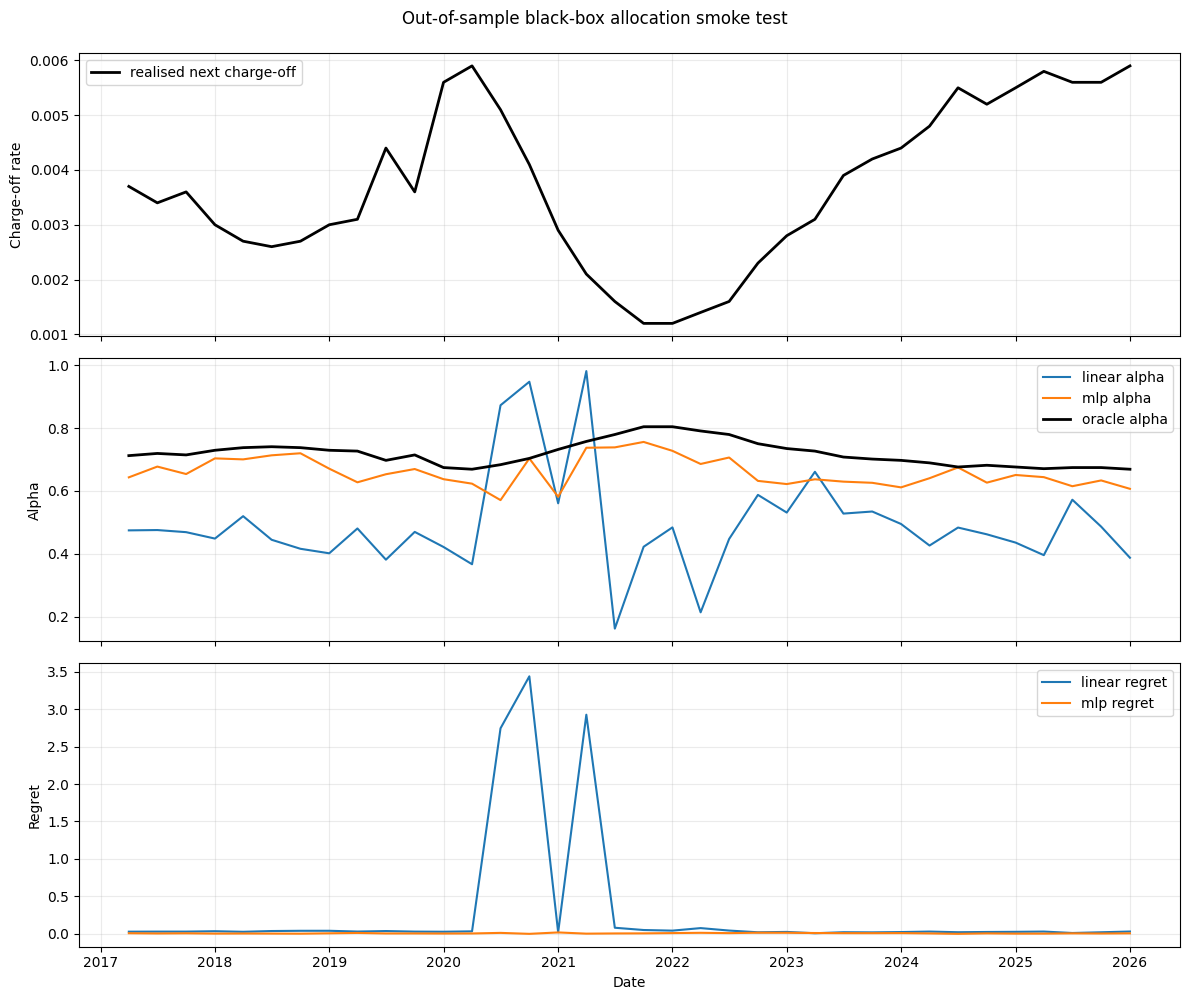

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(test_df["target_date"], y_test, color="black", linewidth=2, label="realised next charge-off")

for model_name, group in predictions.groupby("model"):
    axes[1].plot(group["target_date"], group["alpha_hat"], label=f"{model_name} alpha")
    axes[2].plot(group["target_date"], group["regret"], label=f"{model_name} regret")

oracle = predictions[predictions["model"] == "linear"]
axes[1].plot(oracle["target_date"], oracle["alpha_oracle"], color="black", linewidth=2, label="oracle alpha")

axes[0].set_ylabel("Charge-off rate")
axes[1].set_ylabel("Alpha")
axes[2].set_ylabel("Regret")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Out-of-sample black-box allocation smoke test", y=0.995)
plt.tight_layout()
plt.show()

## Optional expanding-window smoke test

This calls the module's expanding-window routine. It retrains both models for each out-of-sample date, so keep the epoch count low while debugging.

In [7]:
run_expanding_smoke_test = True

if run_expanding_smoke_test:
    expanding_cfg = ModelConfig(
        hidden_dim=16,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=16,
        epochs=500,
        patience=20,
        val_frac=0.2,
        seed=42,
    )
    expanding_predictions, expanding_history = run_expanding_window(
    df=df,
    date_col="DATE",
    feature_cols=feature_cols,
    initial_train_frac=0.75,
    model_cfg=expanding_cfg,
    cap_cfg=cap_cfg,
    return_history=True,
)

display(expanding_predictions.head())
display(expanding_history.head())

TypeError: run_expanding_window() got an unexpected keyword argument 'return_history'

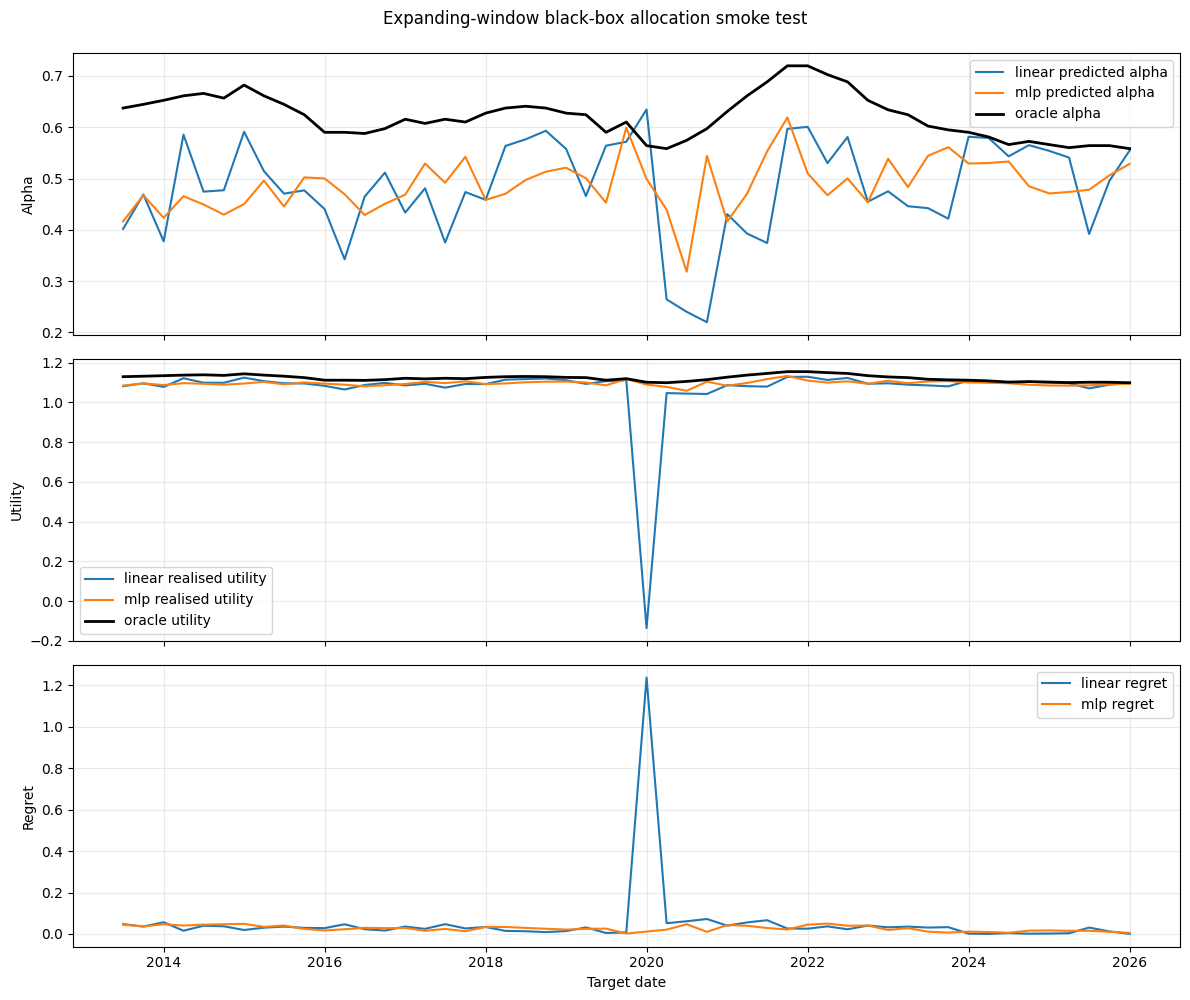

In [ ]:
# Make sure dates are datetime
expanding_predictions["target_date"] = pd.to_datetime(expanding_predictions["target_date"])

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for model_name, group in expanding_predictions.groupby("model"):
    group = group.sort_values("target_date")

    # 1. Predicted alpha over time
    axes[0].plot(
        group["target_date"],
        group["alpha_hat"],
        label=f"{model_name} predicted alpha",
    )

    # 2. Realised utility over time
    axes[1].plot(
        group["target_date"],
        group["realised_utility"],
        label=f"{model_name} realised utility",
    )

    # 3. Regret over time
    axes[2].plot(
        group["target_date"],
        group["regret"],
        label=f"{model_name} regret",
    )

# Oracle alpha and oracle utility are the same across models, so take one model
oracle = (
    expanding_predictions[expanding_predictions["model"] == "linear"]
    .sort_values("target_date")
)

axes[0].plot(
    oracle["target_date"],
    oracle["alpha_oracle"],
    color="black",
    linewidth=2,
    label="oracle alpha",
)

axes[1].plot(
    oracle["target_date"],
    oracle["oracle_utility"],
    color="black",
    linewidth=2,
    label="oracle utility",
)

axes[0].set_ylabel("Alpha")
axes[1].set_ylabel("Utility")
axes[2].set_ylabel("Regret")
axes[2].set_xlabel("Target date")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

fig.suptitle("Expanding-window black-box allocation smoke test", y=0.995)
plt.tight_layout()
plt.show()

In [ ]:
mean_history = (
    expanding_history
    .groupby(["model", "epoch"], as_index=False)
    .agg(
        mean_train_loss=("train_loss", "mean"),
        mean_val_loss=("val_loss", "mean"),
        mean_val_regret=("val_mean_regret", "mean"),
        median_val_regret=("val_mean_regret", "median"),
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

for model_name, group in mean_history.groupby("model"):
    ax.plot(
        group["epoch"],
        group["mean_val_regret"],
        label=f"{model_name} mean validation regret",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean validation regret")
ax.set_title("Average expanding-window validation regret over epochs")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for model_name, group in mean_history.groupby("model"):
    ax.plot(
        group["epoch"],
        group["mean_val_loss"],
        label=f"{model_name} mean validation loss",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean validation loss")
ax.set_title("Average expanding-window validation loss over epochs")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

## Save optional outputs

In [ ]:
output_csv = results_dir / "blackbox_baseline_test_predictions.csv"
predictions.to_csv(output_csv, index=False)
print(f"Saved predictions to {output_csv.relative_to(ROOT)}")

Saved predictions to models/notebooks/.scratch/blackbox_baseline_smoke_test_predictions.csv
